In [9]:
#Dushyant krishna sharma
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

In [11]:
# Independent and dependent variables
X = dataset['text']      # Email content
y = dataset['label']     # spam or ham


In [13]:
# Convert text data into numerical form (Bag of Words)
cv = CountVectorizer()
X = cv.fit_transform(X)

In [15]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [17]:
# Train Naïve Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [19]:
# Predict test set results
y_pred = classifier.predict(X_test)

In [21]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

In [23]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [25]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

In [27]:
print("Confusion Matrix:")
print(cm)

print("\nTrue Positives:", TP)
print("False Positives:", FP)
print("True Negatives:", TN)
print("False Negatives:", FN)

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[908  15]
 [ 14 356]]

True Positives: 356
False Positives: 15
True Negatives: 908
False Negatives: 14

Accuracy: 0.9775715390564579
Error Rate: 0.022428460943542117
Precision: 0.9595687331536388
Recall: 0.9621621621621622


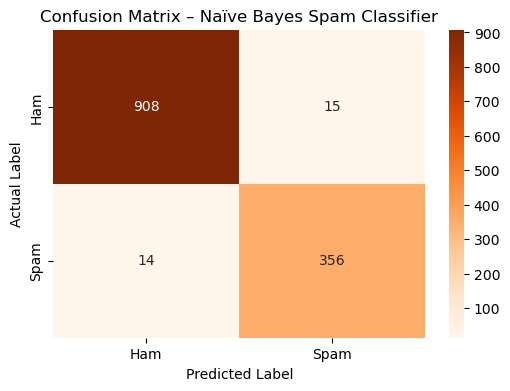

In [29]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix – Naïve Bayes Spam Classifier')
plt.show()